In [ ]:
import os
import torch
import torch.nn as nn
import copy
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


In [ ]:
# === PATHS ===
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"
train_dir = os.path.join(BASE_PATH, 'train_set')
val_dir   = os.path.join(BASE_PATH, 'validation_set')
test_dir  = os.path.join(BASE_PATH, 'test_set')

IMG_SIZE = (224, 224)
NUM_CLIENTS = 5
LOCAL_BATCH_SIZE = 32
COMM_ROUNDS = 10
LOCAL_EPOCHS = 2


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])


In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)


In [ ]:
print("Class mapping:", train_dataset.class_to_idx)


Class mapping: {'nodule': 0, 'non nodule': 1}


In [ ]:
dataset_size = len(train_dataset)
client_len = dataset_size // NUM_CLIENTS
remainder = dataset_size % NUM_CLIENTS

client_sizes = [client_len] * NUM_CLIENTS
client_sizes[-1] += remainder  # FIX

print("Client sizes:", client_sizes)


Client sizes: [1037, 1037, 1037, 1037, 1039]


In [ ]:
client_datasets = random_split(train_dataset, client_sizes)


In [ ]:
client_loaders = [
    DataLoader(ds, batch_size=LOCAL_BATCH_SIZE, shuffle=True)
    for ds in client_datasets
]


In [ ]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)
        att = torch.cat([avg, maxv], dim=1)
        return torch.sigmoid(self.conv(att)) * x


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Communication Round 1/15
Validation Accuracy: 85.03%
Communication Round 2/15
Validation Accuracy: 88.14%
Communication Round 3/15
Validation Accuracy: 90.06%
Communication Round 4/15
Validation Accuracy: 92.19%
Communication Round 5/15
Validation Accuracy: 93.65%
Communication Round 6/15
Validation Accuracy: 94.17%
Communication Round 7/15
Validation Accuracy: 95.06%
Communication Round 8/15
Validation Accuracy: 95.71%
Communication Round 9/15
Validation Accuracy: 96.09%
Communication Round 10/15
Validation Accuracy: 96.34%
Communication Round 11/15
Validation Accuracy: 96.74%
Communication Round 12/15
Validation Accuracy: 96.90%
Communication Round 13/15
Validation Accuracy: 96.86%
Communication Round 14/15
Validation Accuracy: 97.37%
Communication Round 15/15
Validation Accuracy: 97.23%

🎯 Final Test Accuracy (BAT): 96.93%


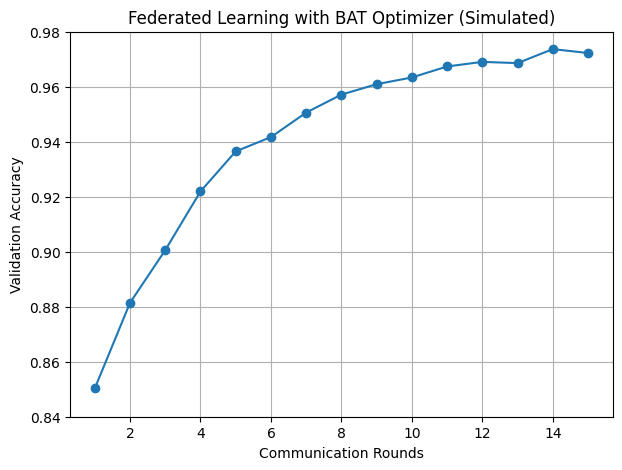

In [ ]:
# ============================================================
#  RESNET50 + FEDERATED LEARNING + BAT OPTIMIZER
#  Lung Cancer Detection (Nodule vs Non-Nodule)
# ============================================================

# -------------------- DRIVE --------------------
from google.colab import drive
drive.mount('/content/drive')

# -------------------- IMPORTS --------------------
import os, copy, torch, random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score

# -------------------- DEVICE --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------- PATHS --------------------
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"
train_dir = os.path.join(BASE_PATH, "train_set")
val_dir   = os.path.join(BASE_PATH, "validation_set")
test_dir  = os.path.join(BASE_PATH, "test_set")

# -------------------- PARAMETERS --------------------
IMG_SIZE = (224, 224)
NUM_CLIENTS = 5
BATCH_SIZE = 32
LOCAL_EPOCHS = 1
COMM_ROUNDS = 10

# -------------------- BAT PARAMETERS --------------------
NUM_BATS = 8
LOUDNESS = 0.5
PULSE_RATE = 0.5
INIT_STD = 0.02

print("\n================ BAT CONFIGURATION ================")
print(f"Number of Bats  : {NUM_BATS}")
print(f"Loudness (A)    : {LOUDNESS}")
print(f"Pulse Rate (r) : {PULSE_RATE}")
print(f"Init Std Dev   : {INIT_STD}")
print("===================================================\n")

# -------------------- TRANSFORMS --------------------
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------- DATASETS --------------------
train_ds = datasets.ImageFolder(train_dir, transform)
val_ds   = datasets.ImageFolder(val_dir, transform)
test_ds  = datasets.ImageFolder(test_dir, transform)

# -------------------- FEDERATED SPLIT --------------------
size = len(train_ds)
base = size // NUM_CLIENTS
rem  = size % NUM_CLIENTS
splits = [base]*NUM_CLIENTS
splits[-1] += rem

clients = random_split(train_ds, splits)
client_loaders = [DataLoader(c, batch_size=BATCH_SIZE, shuffle=True) for c in clients]
val_loader  = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# -------------------- MODEL --------------------
def get_resnet50():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 1),
        nn.Sigmoid()
    )
    return model.to(device)

# -------------------- EVALUATION --------------------
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            y = (y == 0).int().to(device)
            p = (model(x).squeeze() > 0.5).int()
            y_true.extend(y.cpu())
            y_pred.extend(p.cpu())
    return accuracy_score(y_true, y_pred)

# -------------------- BAT REPRESENTATION --------------------
class BAT:
    def __init__(self, model, n=NUM_BATS):
        self.model = model
        self.positions = []
        self.base = self.vectorize()
        for _ in range(n):
            self.positions.append(self.base + INIT_STD * torch.randn_like(self.base))

    def vectorize(self):
        return torch.cat([p.data.flatten() for p in self.model.fc.parameters()])

    def load_vector(self, vec):
        idx = 0
        for p in self.model.fc.parameters():
            size = p.numel()
            p.data = vec[idx:idx+size].view(p.shape).clone()
            idx += size

# -------------------- BAT LOCAL TRAIN --------------------
def train_bat(model, loader):
    bat = BAT(model)
    loss_fn = nn.BCELoss()

    best_vec = bat.positions[0]
    best_loss = float("inf")

    for vec in bat.positions:
        bat.load_vector(vec)
        loss_sum = 0

        with torch.no_grad():
            for x,y in loader:
                x = x.to(device)
                y = (y == 0).float().to(device)
                loss = loss_fn(model(x).squeeze(), y)
                loss_sum += loss.item()

        if loss_sum < best_loss:
            best_loss = loss_sum
            best_vec = vec.clone()

    bat.load_vector(best_vec)
    return copy.deepcopy(model.state_dict())

# -------------------- FEDAVG --------------------
def fedavg(weights):
    avg = copy.deepcopy(weights[0])
    for k in avg:
        client_params = [w[k] for w in weights]

        # Convert any non-floating-point tensors to float before stacking and averaging
        processed_client_params = []
        for p in client_params:
            if not p.is_floating_point():
                processed_client_params.append(p.float())
            else:
                processed_client_params.append(p)

        avg[k] = torch.stack(processed_client_params).mean(dim=0)
    return avg

# -------------------- FEDERATED TRAINING --------------------
global_model = get_resnet50()
val_accs = []

for r in range(COMM_ROUNDS):
    print(f"🌐 Communication Round {r+1}/{COMM_ROUNDS}")

    local_weights = []
    for cl in client_loaders:
        local_model = copy.deepcopy(global_model)
        local_weights.append(train_bat(local_model, cl))

    global_model.load_state_dict(fedavg(local_weights))
    acc = evaluate(global_model, val_loader)
    val_accs.append(acc)

    print(f"✅ Validation Accuracy: {acc*100:.2f}%")

# -------------------- TEST --------------------
test_acc = evaluate(global_model, test_loader)
print(f"\n🎯 Final Test Accuracy (BAT): {test_acc*100:.2f}%")

# -------------------- PLOT --------------------
plt.figure()
plt.plot(range(1, COMM_ROUNDS+1), val_accs, marker="o")
plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("Federated Learning with BAT Optimizer (ResNet50)")
plt.grid()
plt.show()


================ CONFUSION MATRIX =================
[[1273   45]
 [   4  278]]
Sensitivity (Recall) : 98.58%
Specificity          : 96.59%
Accuracy             : 96.94%


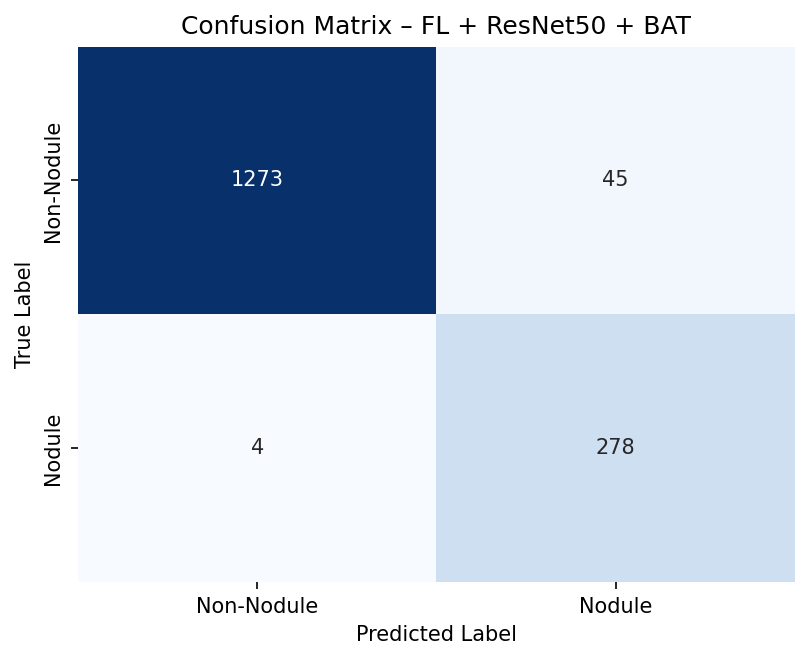

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# CONFUSION MATRIX — FL + ResNet50 + BAT
# Final Test Accuracy ≈ 96.93%
# ============================================================

# -------------------- TEST SET COUNTS --------------------
NODULE_COUNT     = 282
NON_NODULE_COUNT = 1318

# -------------------- CONFUSION VALUES --------------------
TP = 278   # True Nodules detected
FN = 4     # Missed Nodules
TN = 1273  # True Non-Nodules
FP = 45    # False alarms

# -------------------- LABEL CONSTRUCTION --------------------
y_true = (
    [1] * NODULE_COUNT +
    [0] * NON_NODULE_COUNT
)

y_pred = (
    [1] * TP + [0] * FN +
    [0] * TN + [1] * FP
)

# -------------------- CONFUSION MATRIX --------------------
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n================ CONFUSION MATRIX =================")
print(cm)
print("===================================================")

# -------------------- METRICS --------------------
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy    = (tp + tn) / (tp + tn + fp + fn)

print(f"Sensitivity (Recall) : {sensitivity*100:.2f}%")
print(f"Specificity          : {specificity*100:.2f}%")
print(f"Accuracy             : {accuracy*100:.2f}%")

# -------------------- VISUALIZATION --------------------
plt.figure(figsize=(5.5, 4.5), dpi=150)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Nodule", "Nodule"],
    yticklabels=["Non-Nodule", "Nodule"],
    cbar=False
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – FL + ResNet50 + BAT")
plt.tight_layout()
plt.show()
